# Person Scoring (Section 8)

This notebook continues from `13_irt_item_calibration.ipynb` and uses the same `scripts/config.json` → `SAMPLE_VERSION` (default **`strict_fa`**, ~**688** participants).

**Input datasets (paths depend on `SAMPLE_VERSION`):**
- **Theta / IRT:** `.../06_irt_item_calibration/` when `full`, else `.../stepwise_cleaned_versions_<tag>/04_irt_item_calibration/` — `ART_pretest_(for Castano)_EN__irt_theta_scores.csv`.
- **Participant summary & demographics:** `.../05_dimensionality_inputs/` when `full`; for tagged runs, `.../05_dimensionality_inputs/` if present, else `.../03_dimensionality_inputs/` — `...participant_summary.csv` and `...participant_demographics.csv`.

**Output:** `.../07_person_scoring/` when `full`, else `.../stepwise_cleaned_versions_<tag>/05_person_scoring/` — `ART_pretest_(for Castano)_EN__person_scores.csv`.

**Goals:**
1. Examine the distribution of 2PL theta estimates and check for floor/ceiling effects (§8.1).
2. Relate theta to the corrected observed ART score.
3. Check whether theta differs across demographic groups.
4. Report correlations among four score definitions: raw hits, corrected ART score, stronger-penalty score, and theta (§8.2).

**References:**
- Moore & Gordon (2015): compared score definitions and foil-penalty schemes; favoured the 2PL theta as the most psychometrically refined estimate of print exposure.
- McCarron & Kuperman (2022): used 2PL theta for cross-cohort comparisons.


In [1]:
library(mirt)
library(psych)
library(ggplot2)
library(dplyr)
library(reshape2)
library(jsonlite)

mc.cores <- 1
Sys.setenv(MC_CORES = 1)

cat(sprintf("R version: %s.%s\n", R.version$major, R.version$minor))
cat("Package versions:\n")
for (pkg in c("mirt", "psych", "ggplot2", "dplyr", "reshape2", "jsonlite")) {
  cat(sprintf("  %-12s %s\n", pkg, as.character(packageVersion(pkg))))
}

Loading required package: stats4

Loading required package: lattice


Attaching package: ‘ggplot2’


The following objects are masked from ‘package:psych’:

    %+%, alpha



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




R version: 4.5.3
Package versions:
  mirt         1.46.1
  psych        2.6.3
  ggplot2      4.0.2
  dplyr        1.2.0
  reshape2     1.4.5
  jsonlite     2.0.0


## Data loading and merging

In [2]:
PROJECT_ROOT <- normalizePath(file.path("..", ".."), mustWork = TRUE)

config <- fromJSON(file.path(PROJECT_ROOT, "scripts", "config.json"))
SAMPLE_VERSION <- config$SAMPLE_VERSION
RESULTS_TAG <- if (SAMPLE_VERSION == "full") "" else paste0("_", SAMPLE_VERSION)

if (SAMPLE_VERSION == "full") {
  THETA_DIR   <- file.path(PROJECT_ROOT, "data", "stepwise_cleaned_versions",
                           "06_irt_item_calibration")
  DIM_DIR     <- file.path(PROJECT_ROOT, "data", "stepwise_cleaned_versions",
                           "05_dimensionality_inputs")
} else {
  sample_root <- file.path(PROJECT_ROOT, "data",
                           paste0("stepwise_cleaned_versions_", SAMPLE_VERSION))
  THETA_DIR <- file.path(sample_root, "04_irt_item_calibration")
  p05 <- file.path(sample_root, "05_dimensionality_inputs")
  p03 <- file.path(sample_root, "03_dimensionality_inputs")
  DIM_DIR <- if (dir.exists(p05)) p05 else p03
}

cat("SAMPLE_VERSION:", SAMPLE_VERSION, "\n")
cat("Theta dir:     ", THETA_DIR, "\n")
cat("Dim / demo dir:", DIM_DIR, "\n")

theta_df <- read.csv(
  file.path(THETA_DIR,
            "ART_pretest_(for Castano)_EN__irt_theta_scores.csv"),
  stringsAsFactors = FALSE
)

summary_df <- read.csv(
  file.path(DIM_DIR,
            "ART_pretest_(for Castano)_EN__dimensionality_input__participant_summary.csv"),
  stringsAsFactors = FALSE
)

demo_df <- read.csv(
  file.path(DIM_DIR,
            "ART_pretest_(for Castano)_EN__dimensionality_input__participant_demographics.csv"),
  stringsAsFactors = FALSE
)

# Merge all three on participant_id
person_df <- merge(theta_df, summary_df, by = "participant_id", all = TRUE)
person_df <- merge(person_df, demo_df,   by = "participant_id", all = TRUE)

cat("\u2500\u2500 Data loaded \u2500\u2500\n")
cat(sprintf("Theta scores    : %d rows \u00d7 %d cols\n", nrow(theta_df),   ncol(theta_df)))
cat(sprintf("Participant summary : %d rows \u00d7 %d cols\n", nrow(summary_df), ncol(summary_df)))
cat(sprintf("Demographics    : %d rows \u00d7 %d cols\n", nrow(demo_df),    ncol(demo_df)))
cat(sprintf("Merged dataset  : %d rows \u00d7 %d cols\n", nrow(person_df),  ncol(person_df)))
cat(sprintf("Missing theta   : %d\n", sum(is.na(person_df$irt06_theta))))

SAMPLE_VERSION: strict_fa 
Theta dir:      /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/stepwise_cleaned_versions_strict_fa/04_irt_item_calibration 
Dim / demo dir: /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/stepwise_cleaned_versions_strict_fa/03_dimensionality_inputs 
── Data loaded ──
Theta scores    : 688 rows × 3 cols
Participant summary : 688 rows × 11 cols
Demographics    : 688 rows × 5 cols
Merged dataset  : 688 rows × 17 cols
Missing theta   : 0


## Score definitions

Four score types are computed or verified below.

| Score | Formula | Rationale |
|---|---|---|
| **Hits** | `author_hits` | Raw recognition count; ignores foils entirely |
| **Corrected ART score** | `hits − false_alarms` | Standard 1:1 penalty; equivalent to `standard_art_score` in the dataset |
| **Stronger-penalty score** | `hits − (n_foils/n_authors) × false_alarms` | Scales the false-alarm penalty by the foil-to-author ratio (104/98 ≈ 1.061); appropriate when the number of foils differs from the number of author items, as it equates the expected score of a random responder to zero |
| **Theta (2PL)** | `irt06_theta` | EAP latent-trait estimate from the final 2PL model (step 06) |

Moore & Gordon (2015) note that comparing score definitions can strengthen the validity argument for any single score type.

In [3]:
N_AUTHORS <- 98
N_FOILS   <- 104
FOIL_PENALTY_MULTIPLIER <- N_FOILS / N_AUTHORS   # ≈ 1.0612

person_df$hits                  <- person_df$author_hits
person_df$corrected_art_score   <- person_df$hits - person_df$false_alarms
person_df$stronger_penalty_score <- person_df$hits - FOIL_PENALTY_MULTIPLIER * person_df$false_alarms
person_df$theta                 <- person_df$irt06_theta

# Sanity check: corrected_art_score should equal standard_art_score
discrepancy <- sum(abs(person_df$corrected_art_score - person_df$standard_art_score) > 1e-9,
                   na.rm = TRUE)

cat(sprintf("Foil-to-author penalty multiplier : %.4f  (%d foils / %d authors)\n",
            FOIL_PENALTY_MULTIPLIER, N_FOILS, N_AUTHORS))
cat(sprintf("corrected_art_score == standard_art_score : %s (discrepancies = %d)\n",
            ifelse(discrepancy == 0, "TRUE", "FALSE"), discrepancy))
cat("\n")

score_cols <- c("hits", "corrected_art_score", "stronger_penalty_score", "theta")
desc <- psych::describe(person_df[, score_cols])
cat("\u2500\u2500 Score summary statistics \u2500\u2500\n")
print(round(desc[, c("n", "mean", "sd", "min", "max", "skew", "kurtosis")], 3))

Foil-to-author penalty multiplier : 1.0612  (104 foils / 98 authors)
corrected_art_score == standard_art_score : FALSE (discrepancies = 675)

── Score summary statistics ──
                         n  mean    sd    min   max  skew kurtosis
hits                   688 51.46 20.38  11.00 96.00  0.00    -1.03
corrected_art_score    688 47.49 20.95 -18.00 95.00 -0.03    -0.82
stronger_penalty_score 688 47.24 21.02 -19.90 95.00 -0.03    -0.80
theta                  688  0.00  0.98  -2.19  3.35  0.23    -0.18


## 8. Person Scoring

### 8.1 Estimated latent scores (theta distribution)

In [4]:
theta_desc <- psych::describe(person_df$theta)
cat("\u2500\u2500 Theta (2PL EAP) summary \u2500\u2500\n")
cat(sprintf("  N        : %d\n",       theta_desc$n))
cat(sprintf("  Mean     : %.3f\n",     theta_desc$mean))
cat(sprintf("  SD       : %.3f\n",     theta_desc$sd))
cat(sprintf("  Median   : %.3f\n",     theta_desc$median))
cat(sprintf("  Min      : %.3f\n",     theta_desc$min))
cat(sprintf("  Max      : %.3f\n",     theta_desc$max))
cat(sprintf("  Skewness : %.3f\n",     theta_desc$skew))
cat(sprintf("  Kurtosis : %.3f\n",     theta_desc$kurtosis))

# Floor / ceiling: bottom and top 2% thresholds
q02 <- quantile(person_df$theta, 0.02, na.rm = TRUE)
q98 <- quantile(person_df$theta, 0.98, na.rm = TRUE)
n_floor   <- sum(person_df$theta <= q02, na.rm = TRUE)
n_ceiling <- sum(person_df$theta >= q98, na.rm = TRUE)

cat(sprintf("\n  Floor threshold (2nd pctile)   : %.3f  -> %d participants\n", q02, n_floor))
cat(sprintf("  Ceiling threshold (98th pctile): %.3f  -> %d participants\n", q98, n_ceiling))

── Theta (2PL EAP) summary ──
  N        : 688
  Mean     : -0.001
  SD       : 0.985
  Median   : -0.044
  Min      : -2.189
  Max      : 3.354
  Skewness : 0.232
  Kurtosis : -0.182

  Floor threshold (2nd pctile)   : -1.879  -> 14 participants
  Ceiling threshold (98th pctile): 2.098  -> 14 participants


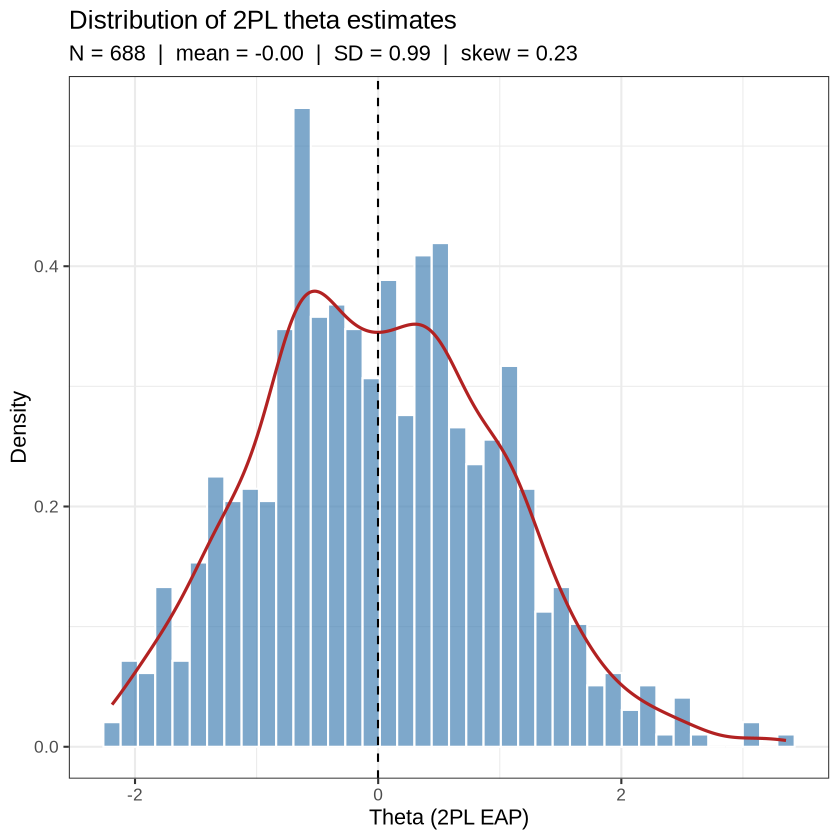

In [5]:
# Histogram with density overlay
ggplot(person_df, aes(x = theta)) +
  geom_histogram(aes(y = after_stat(density)),
                 bins = 40, fill = "steelblue", colour = "white", alpha = 0.7) +
  geom_density(colour = "firebrick", linewidth = 0.9) +
  geom_vline(xintercept = mean(person_df$theta, na.rm = TRUE),
             linetype = "dashed", colour = "black") +
  labs(
    title  = "Distribution of 2PL theta estimates",
    subtitle = sprintf("N = %d  |  mean = %.2f  |  SD = %.2f  |  skew = %.2f",
                       sum(!is.na(person_df$theta)),
                       mean(person_df$theta, na.rm = TRUE),
                       sd(person_df$theta, na.rm = TRUE),
                       psych::describe(person_df$theta)$skew),
    x      = "Theta (2PL EAP)",
    y      = "Density"
  ) +
  theme_bw(base_size = 13)

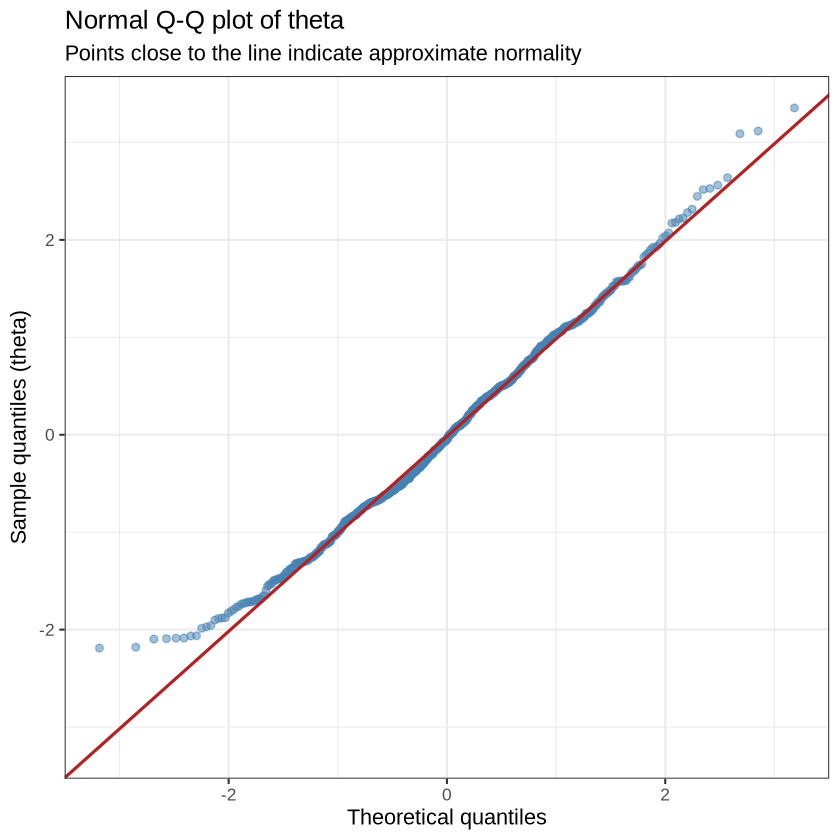

In [6]:
# Q-Q plot to assess normality
ggplot(person_df, aes(sample = theta)) +
  stat_qq(colour = "steelblue", alpha = 0.5) +
  stat_qq_line(colour = "firebrick", linewidth = 0.9) +
  labs(
    title    = "Normal Q-Q plot of theta",
    subtitle = "Points close to the line indicate approximate normality",
    x        = "Theoretical quantiles",
    y        = "Sample quantiles (theta)"
  ) +
  theme_bw(base_size = 13)

### 8.1 (continued) — Relation between theta and corrected ART score

If the 2PL model is a good fit, theta should correlate strongly with the corrected observed score but capture additional psychometric information (e.g., differential item weighting by discrimination).

In [7]:
fmt_p <- function(p) {
  if (is.na(p)) return("= NA")
  if (p < 0.001) return("< .001")
  sprintf("= %.3f", p)
}

r_pearson  <- cor.test(person_df$theta, person_df$corrected_art_score, method = "pearson")
r_spearman <- cor.test(person_df$theta, person_df$corrected_art_score, method = "spearman", exact = FALSE)
r2_pearson <- as.numeric(r_pearson$estimate)^2

cat("\u2500\u2500 Theta ~ Corrected ART score \u2500\u2500\n")
cat(sprintf("  Pearson  r = %.3f (95%% CI [%.3f, %.3f]), p %s\n",
            r_pearson$estimate,
            r_pearson$conf.int[1], r_pearson$conf.int[2],
            fmt_p(r_pearson$p.value)))
cat(sprintf("  Spearman rho = %.3f, p %s\n",
            r_spearman$estimate,
            fmt_p(r_spearman$p.value)))
cat(sprintf("  Shared variance (Pearson r^2) = %.3f\n", r2_pearson))

── Theta ~ Corrected ART score ──
  Pearson  r = 0.958 (95% CI [0.951, 0.963]), p < .001
  Spearman rho = 0.966, p < .001
  Shared variance (Pearson r^2) = 0.917


`geom_smooth()` using formula = 'y ~ x'


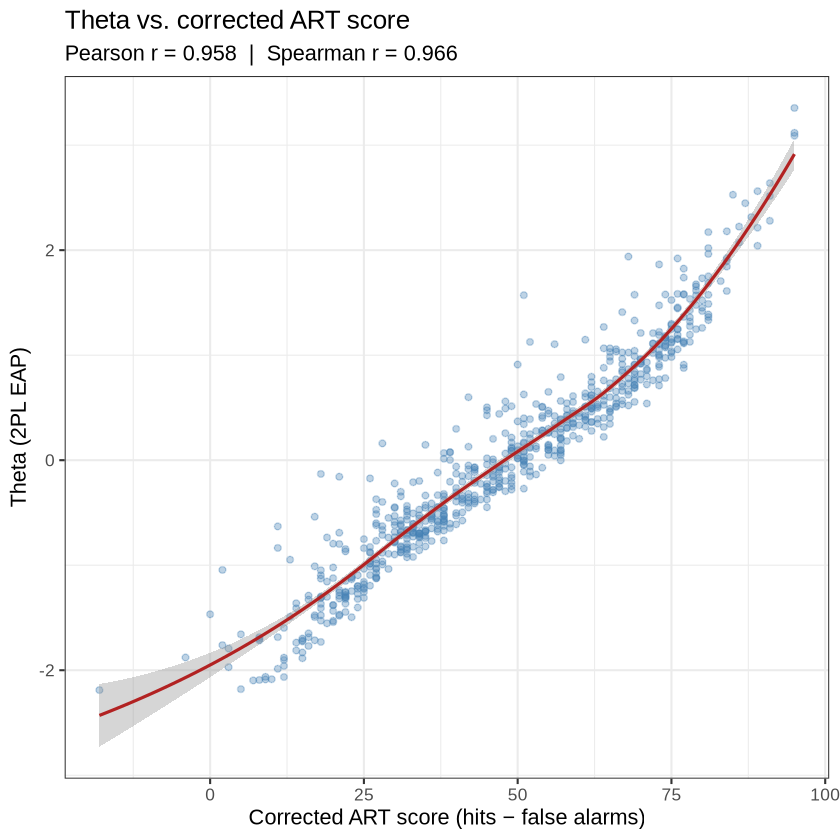

In [8]:
ggplot(person_df, aes(x = corrected_art_score, y = theta)) +
  geom_point(alpha = 0.35, colour = "steelblue", size = 1.5) +
  geom_smooth(method = "loess", colour = "firebrick", linewidth = 0.9, se = TRUE) +
  labs(
    title    = "Theta vs. corrected ART score",
    subtitle = sprintf("Pearson r = %.3f  |  Spearman r = %.3f",
                       r_pearson$estimate, r_spearman$estimate),
    x        = "Corrected ART score (hits \u2212 false alarms)",
    y        = "Theta (2PL EAP)"
  ) +
  theme_bw(base_size = 13)

### 8.1 (continued) — Floor and ceiling effects

IRT theta estimates are bounded by available item information. Participants at the extremes of the theta distribution may have scores that are less precise (higher SE). We inspect the proportion of participants at the extreme tails across all four score types.

In [9]:
# For observed scores, floor = minimum attainable, ceiling = maximum attainable
# For theta, use 2nd / 98th percentile as proxies

floor_ceiling <- data.frame(
  score = score_cols,
  stringsAsFactors = FALSE
)

for (sc in score_cols) {
  x <- person_df[[sc]]
  if (sc == "theta") {
    floor_val   <- quantile(x, 0.02, na.rm = TRUE)
    ceiling_val <- quantile(x, 0.98, na.rm = TRUE)
  } else {
    floor_val   <- min(x, na.rm = TRUE)
    ceiling_val <- max(x, na.rm = TRUE)
  }
  n_floor   <- sum(x <= floor_val, na.rm = TRUE)
  n_ceiling <- sum(x >= ceiling_val, na.rm = TRUE)
  n_total   <- sum(!is.na(x))
  floor_ceiling$floor_val[floor_ceiling$score   == sc] <- round(floor_val, 3)
  floor_ceiling$ceiling_val[floor_ceiling$score == sc] <- round(ceiling_val, 3)
  floor_ceiling$n_floor[floor_ceiling$score     == sc] <- n_floor
  floor_ceiling$n_ceiling[floor_ceiling$score   == sc] <- n_ceiling
  floor_ceiling$pct_floor[floor_ceiling$score   == sc] <- round(100 * n_floor / n_total, 1)
  floor_ceiling$pct_ceiling[floor_ceiling$score == sc] <- round(100 * n_ceiling / n_total, 1)
}

cat("\u2500\u2500 Floor / ceiling check \u2500\u2500\n")
cat("(For theta: 2nd/98th percentile used as proxies)\n\n")
print(floor_ceiling, row.names = FALSE)

── Floor / ceiling check ──
(For theta: 2nd/98th percentile used as proxies)

                  score floor_val ceiling_val n_floor n_ceiling pct_floor
                   hits    11.000      96.000       2         2       0.3
    corrected_art_score   -18.000      95.000       1         3       0.1
 stronger_penalty_score   -19.898      95.000       1         1       0.1
                  theta    -1.879       2.098      14        14       2.0
 pct_ceiling
         0.3
         0.4
         0.1
         2.0


── Mean theta SE by region ──
  theta_region irt06_theta_se
1    Bottom 5%          0.196
2   Middle 90%          0.161
3       Top 5%          0.308


`geom_smooth()` using formula = 'y ~ x'


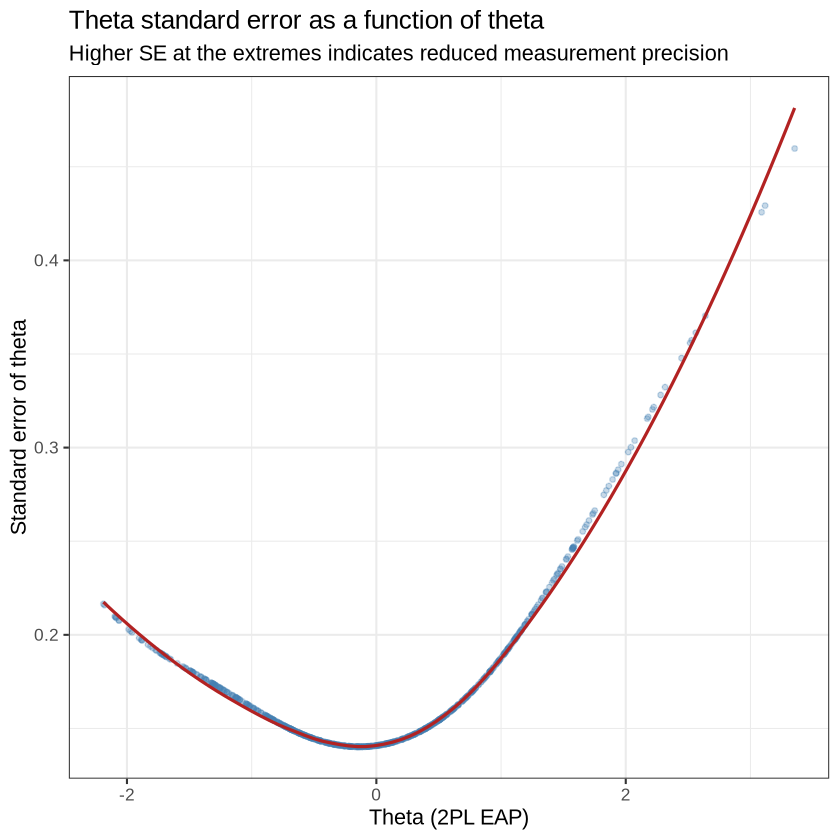

In [10]:
# Theta SE by extreme vs. non-extreme participants
theta_cut <- quantile(person_df$theta, c(0.05, 0.95), na.rm = TRUE)
person_df$theta_region <- ifelse(
  person_df$theta <= theta_cut[1], "Bottom 5%",
  ifelse(person_df$theta >= theta_cut[2], "Top 5%", "Middle 90%")
)
person_df$theta_region <- factor(person_df$theta_region,
                                 levels = c("Bottom 5%", "Middle 90%", "Top 5%"))

se_summary <- aggregate(irt06_theta_se ~ theta_region, data = person_df,
                        FUN = function(x) round(mean(x, na.rm = TRUE), 3))
cat("\u2500\u2500 Mean theta SE by region \u2500\u2500\n")
print(se_summary)

ggplot(person_df, aes(x = theta, y = irt06_theta_se)) +
  geom_point(alpha = 0.3, colour = "steelblue", size = 1.2) +
  geom_smooth(method = "loess", colour = "firebrick", linewidth = 0.9, se = FALSE) +
  labs(
    title    = "Theta standard error as a function of theta",
    subtitle = "Higher SE at the extremes indicates reduced measurement precision",
    x        = "Theta (2PL EAP)",
    y        = "Standard error of theta"
  ) +
  theme_bw(base_size = 13)

### 8.1 (continued) — Theta across demographic groups

Here we test whether estimated print exposure (`theta`) differs across key demographic variables.

- **Sex** and **humanities background** have two groups each, so we use **Welch's t-test** (robust to unequal group variances and unequal sample sizes).
- **Age group** has four groups, so we use **one-way ANOVA** for the omnibus test, then **Tukey post-hoc** comparisons to identify which age groups differ.
- **Profession/education category** has unequal and non-normal-looking groups, so we use **Kruskal-Wallis** (rank-based omnibus test), followed by **pairwise Wilcoxon tests** with Holm correction.

For each test, we report:
- a test statistic and p-value (evidence for group differences), and
- an effect size (magnitude of the difference), so interpretation is not based on p-values alone.

── Theta by sex ──
  sex   n mean_theta sd_theta
1   F 441      0.073    0.931
2   M 247     -0.135    1.065

Welch t-test: t(455.2) = 2.570, p = 0.010
Effect size: Hedges g = 0.212 (small)


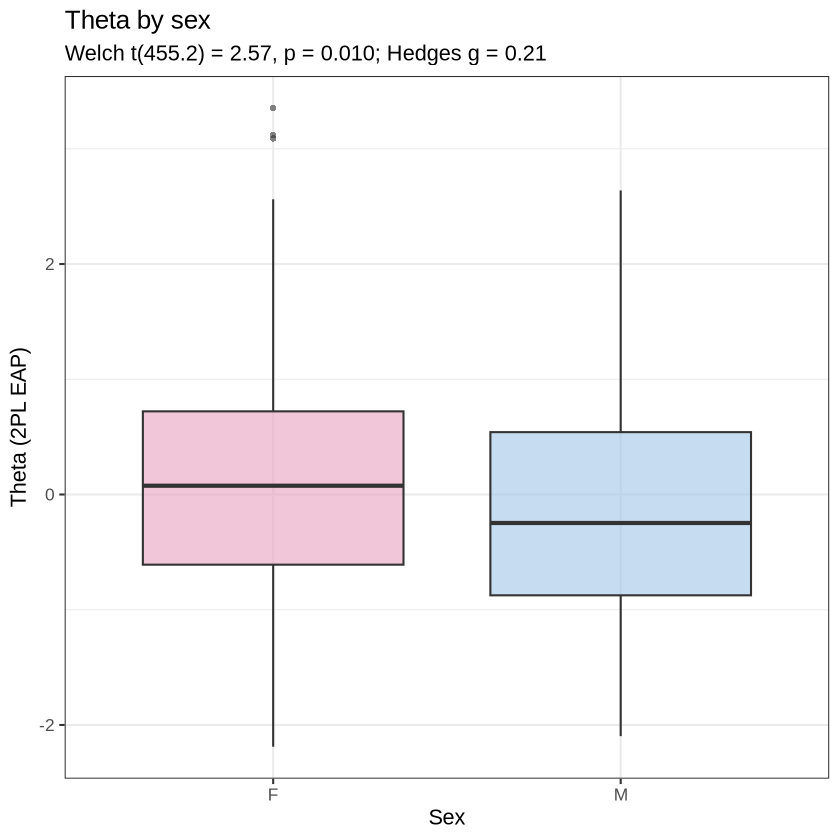

In [11]:
# Recode sex; keep only M/F (drop missing)
person_df$sex_clean <- ifelse(person_df$sex %in% c("M", "F"), person_df$sex, NA)

fmt_p <- function(p) {
  if (is.na(p)) return("= NA")
  if (p < 0.001) return("< .001")
  sprintf("= %.3f", p)
}

interpret_g <- function(g_abs) {
  if (g_abs < 0.20) return("negligible")
  if (g_abs < 0.50) return("small")
  if (g_abs < 0.80) return("medium")
  "large"
}

sex_df <- person_df[!is.na(person_df$sex_clean) & !is.na(person_df$theta), ]
sex_agg <- aggregate(theta ~ sex_clean, data = sex_df,
                     FUN = function(x) c(n = length(x), mean = mean(x), sd = sd(x)))
sex_agg <- do.call(data.frame, sex_agg)
names(sex_agg) <- c("sex", "n", "mean_theta", "sd_theta")

t_sex <- t.test(theta ~ sex_clean, data = sex_df)

x_f <- sex_df$theta[sex_df$sex_clean == "F"]
x_m <- sex_df$theta[sex_df$sex_clean == "M"]
n_f <- length(x_f)
n_m <- length(x_m)
sp <- sqrt(((n_f - 1) * var(x_f) + (n_m - 1) * var(x_m)) / (n_f + n_m - 2))
d_sex <- (mean(x_f) - mean(x_m)) / sp
j_corr <- 1 - 3 / (4 * (n_f + n_m) - 9)
g_sex <- j_corr * d_sex

cat("\u2500\u2500 Theta by sex \u2500\u2500\n")
sex_agg_print <- sex_agg
sex_agg_print[, c("n", "mean_theta", "sd_theta")] <- round(sex_agg_print[, c("n", "mean_theta", "sd_theta")], 3)
print(sex_agg_print)
cat(sprintf("\nWelch t-test: t(%.1f) = %.3f, p %s\n",
            as.numeric(t_sex$parameter),
            as.numeric(t_sex$statistic),
            fmt_p(t_sex$p.value)))
cat(sprintf("Effect size: Hedges g = %.3f (%s)\n",
            g_sex, interpret_g(abs(g_sex))))

p_sex_label <- if (t_sex$p.value < 0.001) "p < .001" else sprintf("p = %.3f", t_sex$p.value)

ggplot(sex_df, aes(x = sex_clean, y = theta, fill = sex_clean)) +
  geom_boxplot(alpha = 0.6, outlier.shape = 16, outlier.size = 1.5) +
  scale_fill_manual(values = c("F" = "#E8A0BF", "M" = "#A0C4E8"), guide = "none") +
  labs(
    title    = "Theta by sex",
    subtitle = sprintf("Welch t(%.1f) = %.2f, %s; Hedges g = %.2f",
                       as.numeric(t_sex$parameter),
                       as.numeric(t_sex$statistic),
                       p_sex_label,
                       g_sex),
    x        = "Sex",
    y        = "Theta (2PL EAP)"
  ) +
  theme_bw(base_size = 13)

── Theta by humanities background ──
           group   n mean_theta sd_theta
1 Non-humanities 449     -0.153    0.946
2     Humanities 159      0.551    0.846

Welch t-test: t(307.5) = -8.738, p < .001
Effect size: Hedges g = 0.764 (medium)


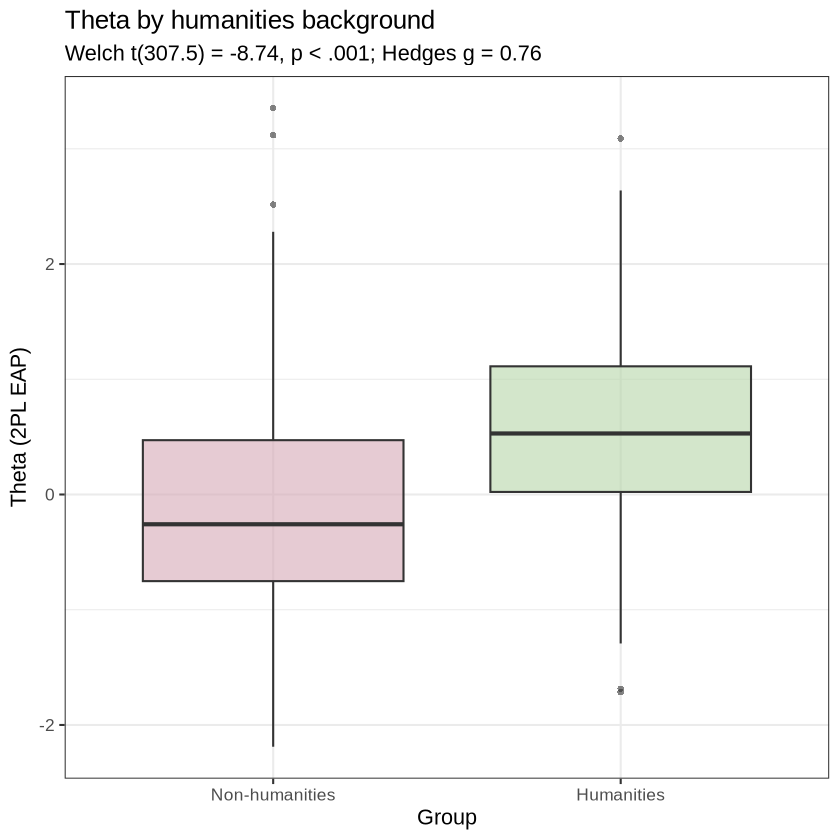

In [12]:
# humanities_or_not: '+' = humanities, '-' = non-humanities; others excluded
person_df$hum_clean <- ifelse(person_df$humanities_or_not %in% c("+", "-"),
                              person_df$humanities_or_not, NA)
hum_df <- person_df[!is.na(person_df$hum_clean) & !is.na(person_df$theta), ]
hum_df$hum_label <- ifelse(hum_df$hum_clean == "+", "Humanities", "Non-humanities")
hum_df$hum_label <- factor(hum_df$hum_label, levels = c("Non-humanities", "Humanities"))

fmt_p <- function(p) {
  if (is.na(p)) return("= NA")
  if (p < 0.001) return("< .001")
  sprintf("= %.3f", p)
}

interpret_g <- function(g_abs) {
  if (g_abs < 0.20) return("negligible")
  if (g_abs < 0.50) return("small")
  if (g_abs < 0.80) return("medium")
  "large"
}

hum_agg <- aggregate(theta ~ hum_label, data = hum_df,
                     FUN = function(x) c(n = length(x), mean = mean(x), sd = sd(x)))
hum_agg <- do.call(data.frame, hum_agg)
names(hum_agg) <- c("group", "n", "mean_theta", "sd_theta")

t_hum <- t.test(theta ~ hum_label, data = hum_df)

x_non <- hum_df$theta[hum_df$hum_label == "Non-humanities"]
x_hum <- hum_df$theta[hum_df$hum_label == "Humanities"]
n_non <- length(x_non)
n_hum <- length(x_hum)
sp <- sqrt(((n_non - 1) * var(x_non) + (n_hum - 1) * var(x_hum)) / (n_non + n_hum - 2))
d_hum <- (mean(x_hum) - mean(x_non)) / sp
j_corr <- 1 - 3 / (4 * (n_non + n_hum) - 9)
g_hum <- j_corr * d_hum

cat("\u2500\u2500 Theta by humanities background \u2500\u2500\n")
hum_agg_print <- hum_agg
hum_agg_print[, c("n", "mean_theta", "sd_theta")] <- round(hum_agg_print[, c("n", "mean_theta", "sd_theta")], 3)
print(hum_agg_print)
cat(sprintf("\nWelch t-test: t(%.1f) = %.3f, p %s\n",
            as.numeric(t_hum$parameter),
            as.numeric(t_hum$statistic),
            fmt_p(t_hum$p.value)))
cat(sprintf("Effect size: Hedges g = %.3f (%s)\n",
            g_hum, interpret_g(abs(g_hum))))

p_hum_label <- if (t_hum$p.value < 0.001) "p < .001" else sprintf("p = %.3f", t_hum$p.value)

ggplot(hum_df, aes(x = hum_label, y = theta, fill = hum_label)) +
  geom_boxplot(alpha = 0.6, outlier.shape = 16, outlier.size = 1.5) +
  scale_fill_manual(values = c("Humanities" = "#B5D5A8", "Non-humanities" = "#D5A8B5"),
                    guide = "none") +
  labs(
    title    = "Theta by humanities background",
    subtitle = sprintf("Welch t(%.1f) = %.2f, %s; Hedges g = %.2f",
                       as.numeric(t_hum$parameter),
                       as.numeric(t_hum$statistic),
                       p_hum_label,
                       g_hum),
    x        = "Group",
    y        = "Theta (2PL EAP)"
  ) +
  theme_bw(base_size = 13)

── Theta by age group ──
  age_group   n mean_theta sd_theta
1      <=25 278     -0.336    0.847
2     26-35 289      0.176    1.062
3     36-50 103      0.328    0.846
4       51+  18      0.425    0.971

One-way ANOVA: F(3, 684) = 20.33, p < .001
Effect size: eta^2 = 0.082, omega^2 = 0.078

Tukey post-hoc comparisons (adjusted p-values):
             diff    lwr   upr p adj
26-35-<=25  0.512  0.307 0.717 0.000
36-50-<=25  0.663  0.382 0.944 0.000
51+-<=25    0.761  0.168 1.354 0.005
36-50-26-35 0.151 -0.128 0.431 0.503
51+-26-35   0.249 -0.343 0.841 0.699
51+-36-50   0.098 -0.525 0.720 0.978

Continuous-age association: Pearson r = 0.266 (p < .001), Spearman rho = 0.331 (p < .001)


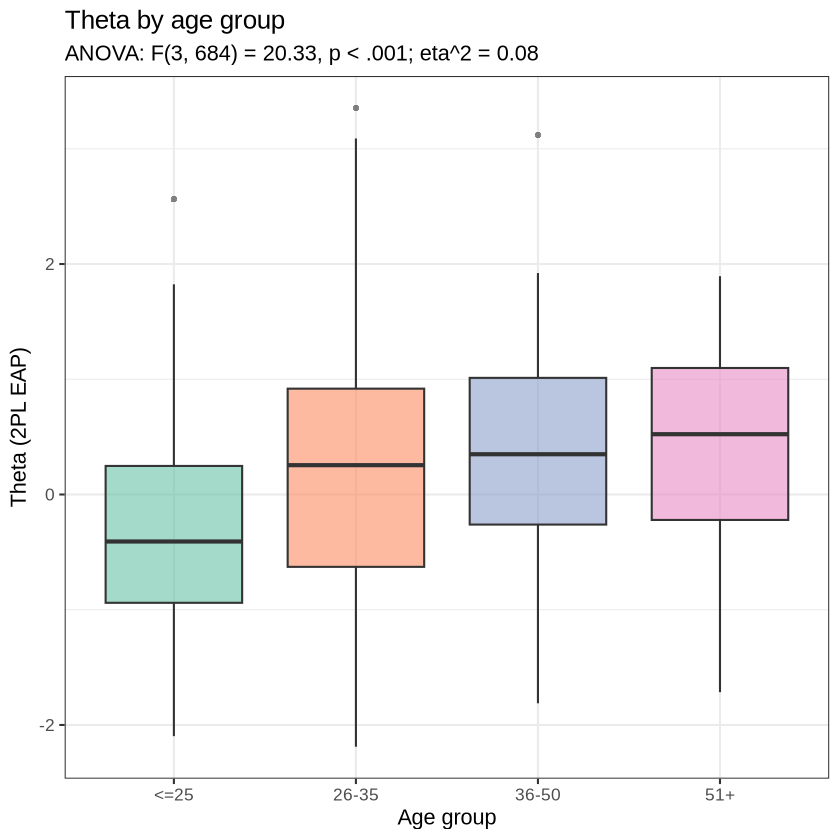

In [13]:
# Age groups
person_df$age_group <- cut(
  person_df$age,
  breaks = c(-Inf, 25, 35, 50, Inf),
  labels = c("<=25", "26-35", "36-50", "51+"),
  right  = TRUE
)

fmt_p <- function(p) {
  if (is.na(p)) return("= NA")
  if (p < 0.001) return("< .001")
  sprintf("= %.3f", p)
}

age_df <- person_df[!is.na(person_df$age_group) & !is.na(person_df$theta) & !is.na(person_df$age), ]

age_agg <- aggregate(theta ~ age_group, data = age_df,
                     FUN = function(x) c(n = length(x), mean = mean(x), sd = sd(x)))
age_agg <- do.call(data.frame, age_agg)
names(age_agg) <- c("age_group", "n", "mean_theta", "sd_theta")

aov_age <- aov(theta ~ age_group, data = age_df)
aov_summary <- summary(aov_age)[[1]]

ss_between <- aov_summary[["Sum Sq"]][1]
ss_within  <- aov_summary[["Sum Sq"]][2]
ss_total   <- ss_between + ss_within
ms_within  <- aov_summary[["Mean Sq"]][2]
k_groups   <- nlevels(age_df$age_group)

eta2_age <- ss_between / ss_total
omega2_age <- (ss_between - (k_groups - 1) * ms_within) / (ss_total + ms_within)
omega2_age <- max(0, omega2_age)

tukey_age <- TukeyHSD(aov_age, "age_group")

age_cor_pearson <- cor.test(age_df$age, age_df$theta, method = "pearson")
age_cor_spearman <- cor.test(age_df$age, age_df$theta, method = "spearman", exact = FALSE)

cat("\u2500\u2500 Theta by age group \u2500\u2500\n")
age_agg_print <- age_agg
age_agg_print[, c("n", "mean_theta", "sd_theta")] <- round(age_agg_print[, c("n", "mean_theta", "sd_theta")], 3)
print(age_agg_print)

cat(sprintf("\nOne-way ANOVA: F(%d, %d) = %.2f, p %s\n",
            as.integer(aov_summary[["Df"]][1]),
            as.integer(aov_summary[["Df"]][2]),
            as.numeric(aov_summary[["F value"]][1]),
            fmt_p(aov_summary[["Pr(>F)"]][1])))
cat(sprintf("Effect size: eta^2 = %.3f, omega^2 = %.3f\n", eta2_age, omega2_age))

cat("\nTukey post-hoc comparisons (adjusted p-values):\n")
print(round(tukey_age$age_group, 3))

cat(sprintf("\nContinuous-age association: Pearson r = %.3f (p %s), Spearman rho = %.3f (p %s)\n",
            as.numeric(age_cor_pearson$estimate),
            fmt_p(age_cor_pearson$p.value),
            as.numeric(age_cor_spearman$estimate),
            fmt_p(age_cor_spearman$p.value)))

p_age_label <- if (aov_summary[["Pr(>F)"]][1] < 0.001) "p < .001" else sprintf("p = %.3f", aov_summary[["Pr(>F)"]][1])

ggplot(age_df, aes(x = age_group, y = theta, fill = age_group)) +
  geom_boxplot(alpha = 0.6, outlier.shape = 16, outlier.size = 1.5) +
  scale_fill_brewer(palette = "Set2", guide = "none") +
  labs(
    title    = "Theta by age group",
    subtitle = sprintf("ANOVA: F(%d, %d) = %.2f, %s; eta^2 = %.2f",
                       as.integer(aov_summary[["Df"]][1]),
                       as.integer(aov_summary[["Df"]][2]),
                       as.numeric(aov_summary[["F value"]][1]),
                       p_age_label,
                       eta2_age),
    x        = "Age group",
    y        = "Theta (2PL EAP)"
  ) +
  theme_bw(base_size = 13)

── Theta by profession / education category ──
             profession   n mean_theta sd_theta
1 Science and Education 217      0.309    0.843
2      Service Industry 191     -0.072    0.990
3    IT and Engineering 115     -0.356    0.990
4       Art and Culture  49      0.328    0.939
5        Student/School  19     -0.606    0.627

Kruskal-Wallis: chi-squared = 59.326, df = 4, p < .001
Effect size: epsilon^2 = 0.094

Pairwise Wilcoxon tests (Holm-adjusted p-values):
                   Science and Education Service Industry IT and Engineering
Service Industry                   0.000               NA                 NA
IT and Engineering                 0.000            0.055                 NA
Art and Culture                    0.874            0.055              0.000
Student/School                     0.000            0.056              0.615
                   Art and Culture
Service Industry                NA
IT and Engineering              NA
Art and Culture                 NA
St

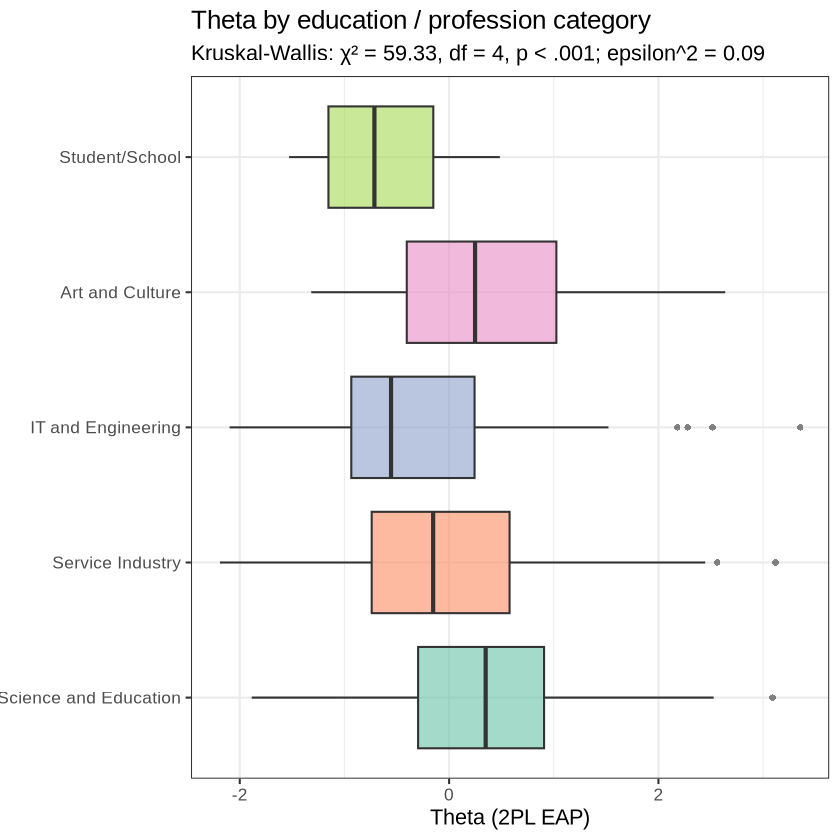

In [14]:
# education_and_profession — keep labelled categories, exclude Missing/Unknown
valid_profs <- c("Science and Education", "Service Industry", "IT and Engineering",
                 "Art and Culture", "Student/School")

fmt_p <- function(p) {
  if (is.na(p)) return("= NA")
  if (p < 0.001) return("< .001")
  sprintf("= %.3f", p)
}

prof_df <- person_df[
  person_df$education_and_profession %in% valid_profs & !is.na(person_df$theta), 
]
prof_df$education_and_profession <- factor(
  prof_df$education_and_profession,
  levels = valid_profs
)

prof_agg <- aggregate(theta ~ education_and_profession, data = prof_df,
                      FUN = function(x) c(n = length(x), mean = mean(x), sd = sd(x)))
prof_agg <- do.call(data.frame, prof_agg)
names(prof_agg) <- c("profession", "n", "mean_theta", "sd_theta")

kw_prof <- kruskal.test(theta ~ education_and_profession, data = prof_df)

k_groups <- nlevels(prof_df$education_and_profession)
n_total <- nrow(prof_df)
epsilon2_prof <- (as.numeric(kw_prof$statistic) - k_groups + 1) / (n_total - k_groups)
epsilon2_prof <- max(0, epsilon2_prof)

pairwise_prof <- pairwise.wilcox.test(
  x = prof_df$theta,
  g = prof_df$education_and_profession,
  p.adjust.method = "holm",
  exact = FALSE
)

cat("\u2500\u2500 Theta by profession / education category \u2500\u2500\n")
prof_agg_print <- prof_agg
prof_agg_print[, c("n", "mean_theta", "sd_theta")] <- round(prof_agg_print[, c("n", "mean_theta", "sd_theta")], 3)
print(prof_agg_print)
cat(sprintf("\nKruskal-Wallis: chi-squared = %.3f, df = %d, p %s\n",
            as.numeric(kw_prof$statistic), as.integer(kw_prof$parameter), fmt_p(kw_prof$p.value)))
cat(sprintf("Effect size: epsilon^2 = %.3f\n", epsilon2_prof))

cat("\nPairwise Wilcoxon tests (Holm-adjusted p-values):\n")
print(round(pairwise_prof$p.value, 3))

p_prof_label <- if (kw_prof$p.value < 0.001) "p < .001" else sprintf("p = %.3f", kw_prof$p.value)

ggplot(prof_df, aes(x = education_and_profession, y = theta, fill = education_and_profession)) +
  geom_boxplot(alpha = 0.6, outlier.shape = 16, outlier.size = 1.5) +
  scale_fill_brewer(palette = "Set2", guide = "none") +
  coord_flip() +
  labs(
    title    = "Theta by education / profession category",
    subtitle = sprintf("Kruskal-Wallis: \u03c7\u00b2 = %.2f, df = %d, %s; epsilon^2 = %.2f",
                       as.numeric(kw_prof$statistic),
                       as.integer(kw_prof$parameter),
                       p_prof_label,
                       epsilon2_prof),
    x        = NULL,
    y        = "Theta (2PL EAP)"
  ) +
  theme_bw(base_size = 13)

### 8.2 Score-type comparison

Following Moore & Gordon (2015), we compare all four score definitions to check whether they rank participants similarly.

- **Hits**: raw author recognition count (no foil correction).
- **Corrected ART score**: hits − false alarms (standard 1:1 correction).
- **Stronger-penalty score**: hits − (104/98) × false alarms (proportional correction).
- **Theta**: 2PL EAP estimate; weights items by discrimination and difficulty.

We report both:
- **Pearson correlations** (linear agreement in metric scale), and
- **Spearman correlations** (rank-order agreement, robust to monotonic nonlinearity).

For transparency, we also report pairwise p-values (with BH-adjusted p-values) and 95% CIs for Pearson *r*.

In [15]:
fmt_p <- function(p) {
  if (is.na(p)) return("= NA")
  if (p < 0.001) return("< .001")
  sprintf("= %.3f", p)
}

score_mat_report <- person_df[, score_cols]
names(score_mat_report) <- c("Hits", "Corrected ART", "Stronger penalty", "Theta")

# Keep line breaks in labels for the scatter-matrix panel layout.
score_mat <- score_mat_report
names(score_mat) <- c("Hits", "Corrected\nART", "Stronger\npenalty", "Theta")

cor_pearson  <- cor(score_mat_report, method = "pearson",  use = "complete.obs")
cor_spearman <- cor(score_mat_report, method = "spearman", use = "complete.obs")

cat("\u2500\u2500 Pearson correlations \u2500\u2500\n")
print(round(cor_pearson, 3))
cat("\n\u2500\u2500 Spearman correlations \u2500\u2500\n")
print(round(cor_spearman, 3))

pair_ids <- combn(names(score_mat_report), 2, simplify = FALSE)
pairwise_corr <- do.call(rbind, lapply(pair_ids, function(v) {
  x <- score_mat_report[[v[1]]]
  y <- score_mat_report[[v[2]]]

  ct_p <- cor.test(x, y, method = "pearson")
  ct_s <- cor.test(x, y, method = "spearman", exact = FALSE)

  data.frame(
    pair = paste(v[1], "↔", v[2]),
    pearson_r = as.numeric(ct_p$estimate),
    pearson_ci_low = as.numeric(ct_p$conf.int[1]),
    pearson_ci_high = as.numeric(ct_p$conf.int[2]),
    pearson_p = ct_p$p.value,
    spearman_rho = as.numeric(ct_s$estimate),
    spearman_p = ct_s$p.value,
    stringsAsFactors = FALSE
  )
}))

pairwise_corr$pearson_p_adj_bh  <- p.adjust(pairwise_corr$pearson_p,  method = "BH")
pairwise_corr$spearman_p_adj_bh <- p.adjust(pairwise_corr$spearman_p, method = "BH")

pairwise_out <- data.frame(
  Pair = pairwise_corr$pair,
  `Pearson r` = sprintf("%.3f", pairwise_corr$pearson_r),
  `95% CI` = sprintf("[%.3f, %.3f]", pairwise_corr$pearson_ci_low, pairwise_corr$pearson_ci_high),
  `Pearson p` = vapply(pairwise_corr$pearson_p, fmt_p, character(1)),
  `Pearson p (BH)` = vapply(pairwise_corr$pearson_p_adj_bh, fmt_p, character(1)),
  `Spearman rho` = sprintf("%.3f", pairwise_corr$spearman_rho),
  `Spearman p` = vapply(pairwise_corr$spearman_p, fmt_p, character(1)),
  `Spearman p (BH)` = vapply(pairwise_corr$spearman_p_adj_bh, fmt_p, character(1)),
  check.names = FALSE,
  stringsAsFactors = FALSE
)

cat("\n\u2500\u2500 Pairwise correlation tests (with BH-adjusted p-values) \u2500\u2500\n")
print(pairwise_out, row.names = FALSE)

── Pearson correlations ──
                  Hits Corrected ART Stronger penalty Theta
Hits             1.000         0.969            0.965 0.985
Corrected ART    0.969         1.000            1.000 0.958
Stronger penalty 0.965         1.000            1.000 0.954
Theta            0.985         0.958            0.954 1.000

── Spearman correlations ──
                  Hits Corrected ART Stronger penalty Theta
Hits             1.000         0.971            0.968 0.994
Corrected ART    0.971         1.000            1.000 0.966
Stronger penalty 0.968         1.000            1.000 0.962
Theta            0.994         0.966            0.962 1.000

── Pairwise correlation tests (with BH-adjusted p-values) ──
                             Pair Pearson r         95% CI Pearson p
             Hits ↔ Corrected ART     0.969 [0.964, 0.973]    < .001
          Hits ↔ Stronger penalty     0.965 [0.960, 0.970]    < .001
                     Hits ↔ Theta     0.985 [0.983, 0.987]    < .001
 Corre

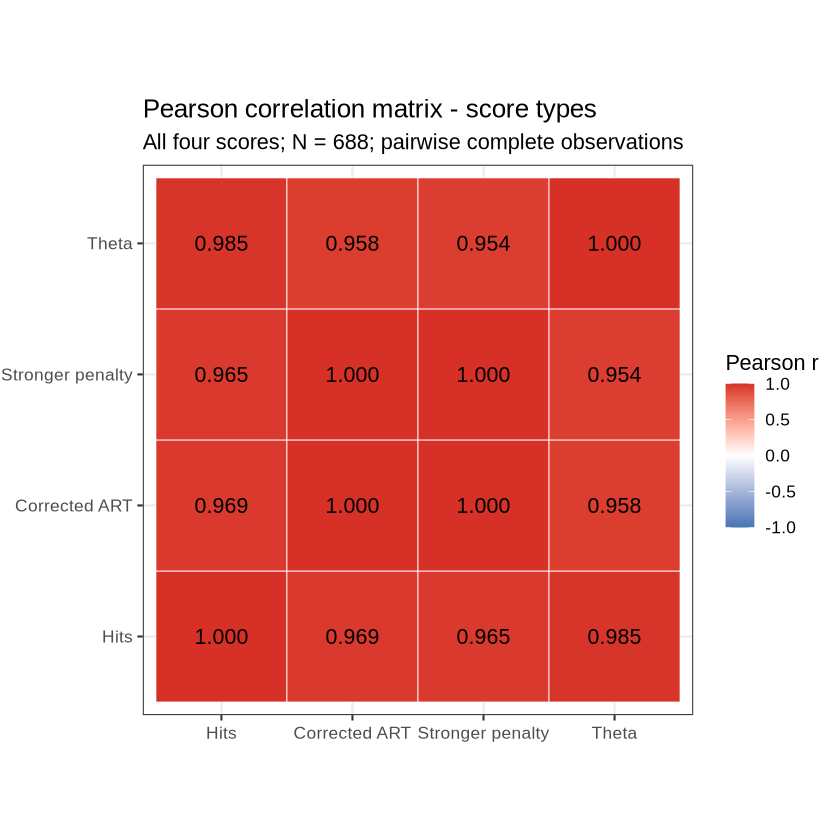

In [16]:
# Heatmap — Pearson
n_cor_complete <- sum(complete.cases(score_mat_report))
cor_long <- melt(cor_pearson)
names(cor_long) <- c("Var1", "Var2", "r")
cor_long$label <- sprintf("%.3f", cor_long$r)

ggplot(cor_long, aes(x = Var1, y = Var2, fill = r)) +
  geom_tile(colour = "white") +
  geom_text(aes(label = label), size = 4.5) +
  scale_fill_gradient2(
    low = "#4575B4", mid = "white", high = "#D73027",
    midpoint = 0, limits = c(-1, 1), name = "Pearson r"
  ) +
  labs(
    title    = "Pearson correlation matrix - score types",
    subtitle = sprintf("All four scores; N = %d; pairwise complete observations", n_cor_complete),
    x        = NULL,
    y        = NULL
  ) +
  coord_fixed() +
  theme_bw(base_size = 13) +
  theme(axis.text.x = element_text(angle = 0, vjust = 0.5))

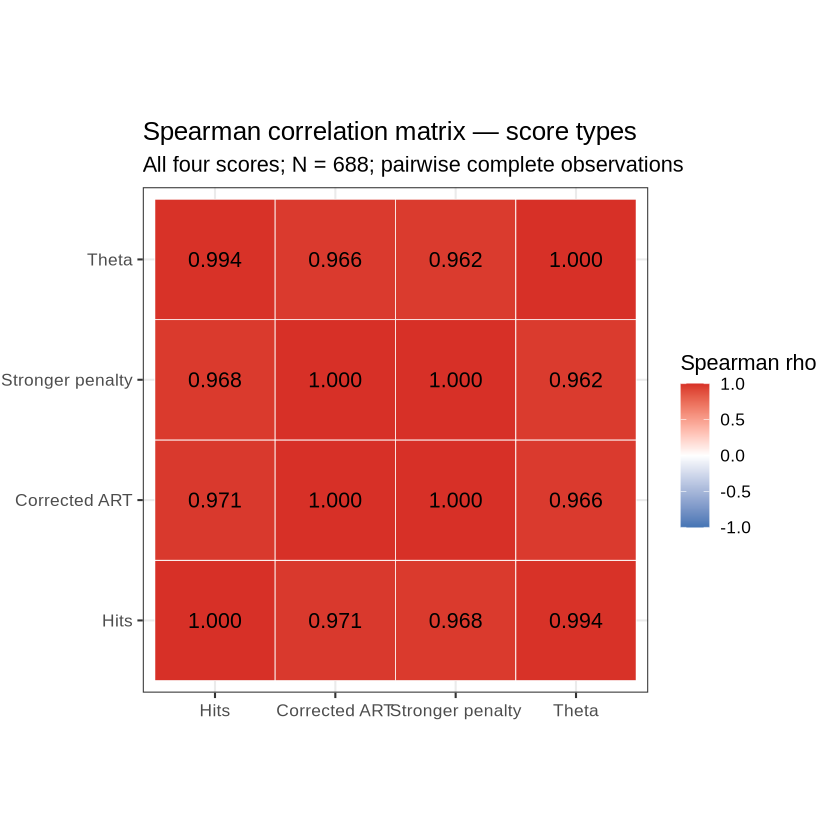

In [17]:
# Heatmap — Spearman
n_cor_complete_sp <- sum(complete.cases(score_mat_report))
cor_long_sp <- melt(cor_spearman)
names(cor_long_sp) <- c("Var1", "Var2", "r")
cor_long_sp$label <- sprintf("%.3f", cor_long_sp$r)

ggplot(cor_long_sp, aes(x = Var1, y = Var2, fill = r)) +
  geom_tile(colour = "white") +
  geom_text(aes(label = label), size = 4.5) +
  scale_fill_gradient2(
    low = "#4575B4", mid = "white", high = "#D73027",
    midpoint = 0, limits = c(-1, 1), name = "Spearman rho"
  ) +
  labs(
    title    = "Spearman correlation matrix — score types",
    subtitle = sprintf("All four scores; N = %d; pairwise complete observations", n_cor_complete_sp),
    x        = NULL,
    y        = NULL
  ) +
  coord_fixed() +
  theme_bw(base_size = 13) +
  theme(axis.text.x = element_text(angle = 0, vjust = 0.5))

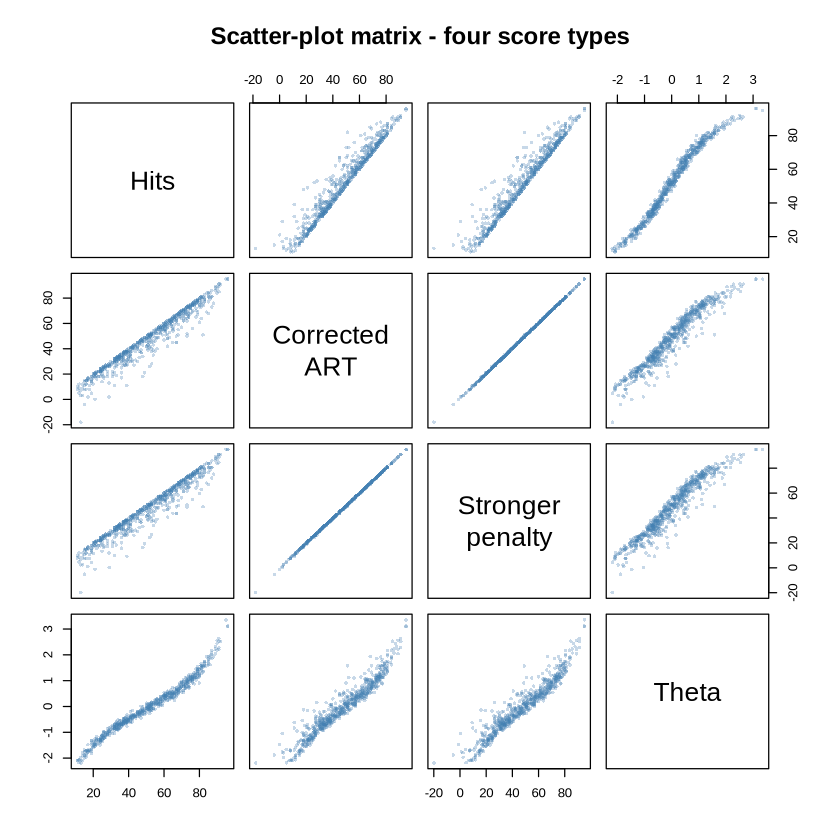

In [18]:
# Scatter-plot matrix for a fuller picture
pairs(
  score_mat,
  labels = c("Hits", "Corrected\nART", "Stronger\npenalty", "Theta"),
  pch    = 16,
  col    = adjustcolor("steelblue", alpha.f = 0.3),
  cex    = 0.6,
  main   = "Scatter-plot matrix - four score types"
)

## Export

The enriched person-level CSV is written under `07_person_scoring/` for **`full`**, or `stepwise_cleaned_versions_<tag>/05_person_scoring/` for tagged samples (see the export cell).


In [19]:
if (SAMPLE_VERSION == "full") {
  OUTPUT_DIR <- file.path(PROJECT_ROOT, "data", "stepwise_cleaned_versions",
                          "07_person_scoring")
} else {
  OUTPUT_DIR <- file.path(PROJECT_ROOT, "data",
                          paste0("stepwise_cleaned_versions_", SAMPLE_VERSION),
                          "05_person_scoring")
}
dir.create(OUTPUT_DIR, recursive = TRUE, showWarnings = FALSE)

export_cols <- c(
  "participant_id",
  # IRT scores
  "irt06_theta", "irt06_theta_se",
  # Observed scores
  "hits", "false_alarms",
  "corrected_art_score", "stronger_penalty_score",
  # Demographics
  "age", "sex", "humanities_or_not", "education_and_profession",
  # Derived
  "age_group", "sex_clean", "hum_clean"
)
export_cols_present <- intersect(export_cols, names(person_df))

out_df  <- person_df[, export_cols_present]
out_file <- file.path(OUTPUT_DIR,
                      "ART_pretest_(for Castano)_EN__person_scores.csv")
write.csv(out_df, file = out_file, row.names = FALSE)

cat("\u2500\u2500 Export complete \u2500\u2500\n")
cat(sprintf("  Rows    : %d\n",  nrow(out_df)))
cat(sprintf("  Columns : %d\n",  ncol(out_df)))
cat(sprintf("  File    : %s\n",  basename(out_file)))
cat(sprintf("  Path    : %s\n",  out_file))

── Export complete ──
  Rows    : 688
  Columns : 14
  File    : ART_pretest_(for Castano)_EN__person_scores.csv
  Path    : /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/stepwise_cleaned_versions_strict_fa/05_person_scoring/ART_pretest_(for Castano)_EN__person_scores.csv


In [20]:
# Article package export (CSV tables + PNG/PDF figures for manuscript)

export_script <- file.path(PROJECT_ROOT, "scripts", "irt_analysis", "16_export_article_package.R")
source(export_script, local = FALSE)

Wrote /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/results/person_scoring_strict_fa_article_package_2026-04-06/table_score_type_descriptives.csv

Wrote /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/results/person_scoring_strict_fa_article_package_2026-04-06/table_theta_descriptives_detail.csv

Wrote /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/results/person_scoring_strict_fa_article_package_2026-04-06/table_floor_ceiling_analysis.csv

Wrote /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/results/person_scoring_strict_fa_article_package_2026-04-06/table_theta_se_by_region.csv

Wrote /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/results/person_scoring_strict_fa_article_package_2026-04-06/table_group_comparison_sex_descriptives.csv

Wrote /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/results/person_

In [22]:
library(mirt)
library(psych)
library(ggplot2)
library(dplyr)
library(reshape2)
library(jsonlite)

mc.cores <- 1
Sys.setenv(MC_CORES = 1)

cat(sprintf("R version: %s.%s\n", R.version$major, R.version$minor))
cat("Package versions:\n")
for (pkg in c("mirt", "psych", "ggplot2", "dplyr", "reshape2", "jsonlite")) {
  cat(sprintf("  %-12s %s\n", pkg, as.character(packageVersion(pkg))))
}

R version: 4.5.3
Package versions:
  mirt         1.46.1
  psych        2.6.3
  ggplot2      4.0.2
  dplyr        1.2.0
  reshape2     1.4.5
  jsonlite     2.0.0
